<a href="https://colab.research.google.com/github/twillixa/HEC/blob/main/PPS/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:

!pip install pulp numpy pandas matplotlib
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt


In [1]:
def simulate_plan(
    demand,
    production_per_worker_regular,
    starting_inventory,
    desired_ending_inventory,
    initial_workers,
    wage_per_worker,
    hire_cost,
    layoff_cost,
    inventory_cost_per_unit,
    overtime_months,
    overtime_percentage,
    overtime_wage_multiplier,
    strategy,
):
    months = len(demand)
    overtime_months = set(overtime_months or [])
    demand = np.array(demand, dtype=float)

    # workforce arrays
    workers = np.zeros(months)
    hired = np.zeros(months)
    laid_off = np.zeros(months)
    inventory = np.zeros(months + 1)
    inventory[0] = starting_inventory

    # helper: overtime factor by month
    ot_flag = np.array([1.0 if t in overtime_months else 0.0 for t in range(months)])
    prod_per_worker = production_per_worker_regular * (1 + ot_flag * overtime_percentage)

    # choose workforce rule
    if strategy == "chase":
        workers_needed = np.ceil(demand / production_per_worker_regular)
    else:
        total_required = demand.sum() + desired_ending_inventory - starting_inventory
        total_capacity_per_worker = prod_per_worker.sum()
        w_const = int(np.ceil(total_required / total_capacity_per_worker))
        workers_needed = np.full(months, w_const)

    # simulate month-by-month
    for t in range(months):
        workers[t] = workers_needed[t]
        if t == 0:
            hired[t] = max(0, workers[t] - initial_workers)
            laid_off[t] = max(0, initial_workers - workers[t])
        else:
            hired[t] = max(0, workers[t] - workers[t-1])
            laid_off[t] = max(0, workers[t-1] - workers[t])
        produced = workers[t] * prod_per_worker[t]
        inventory[t+1] = inventory[t] + produced - demand[t]

    # costs
    wage_cost = workers * wage_per_worker
    hiring_cost = hired * hire_cost
    layoff_costs = laid_off * layoff_cost
    inv_cost = inventory[1:] * inventory_cost_per_unit
    overtime_cost = workers * wage_per_worker * (ot_flag * overtime_percentage) * overtime_wage_multiplier

    total_monthly = wage_cost + hiring_cost + layoff_costs + inv_cost + overtime_cost

    df = pd.DataFrame({
        "Month": np.arange(1, months+1),
        "Workers": workers,
        "Hired": hired,
        "Laid off": laid_off,
        "Produced": workers * prod_per_worker,
        "Demand": demand,
        "End Inventory": inventory[1:],
        "Wage Cost": wage_cost,
        "Overtime Cost": overtime_cost,
        "Hiring Cost": hiring_cost,
        "Layoff Cost": layoff_costs,
        "Inventory Cost": inv_cost,
        "Total Cost": total_monthly,
    })

    summary = {
        "Total Wage": float(wage_cost.sum()),
        "Total Overtime": float(overtime_cost.sum()),
        "Total Hiring": float(hiring_cost.sum()),
        "Total Layoff": float(layoff_costs.sum()),
        "Total Inventory": float(inv_cost.sum()),
        "Grand Total": float(total_monthly.sum()),
    }

    return df, summary

In [9]:
df_level, s_level = simulate_plan(
    demand                        = [300, 300, 350, 400, 450, 500, 650, 600, 475, 475, 450, 450],
    production_per_worker_regular = 10,
    starting_inventory            = 50,
    desired_ending_inventory      = 50,
    initial_workers               = 40,
    wage_per_worker               = 2,
    hire_cost                     = 1,
    layoff_cost                   = 2,
    inventory_cost_per_unit       = 0.06,
    overtime_months               = [5, 6, 7],
    overtime_percentage           = 0.2,
    overtime_wage_multiplier      = 1.5,
    strategy                      = "mixed",
)
display(df_level)
s_level

,Month,Workers,Hired,Laid off,Produced,Demand,End Inventory,Wage Cost,Overtime Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,1,43.0,3.0,0.0,430.0,300.0,180.0,86.0,0.0,3.0,0.0,10.80,99.80
1,2,43.0,0.0,0.0,430.0,300.0,310.0,86.0,0.0,0.0,0.0,18.60,104.60
2,3,43.0,0.0,0.0,430.0,350.0,390.0,86.0,0.0,0.0,0.0,23.40,109.40
3,4,43.0,0.0,0.0,430.0,400.0,420.0,86.0,0.0,0.0,0.0,25.20,111.20
4,5,43.0,0.0,0.0,430.0,450.0,400.0,86.0,0.0,0.0,0.0,24.00,110.00
5,6,43.0,0.0,0.0,516.0,500.0,416.0,86.0,25.8,0.0,0.0,24.96,136.76
6,7,43.0,0.0,0.0,516.0,650.0,282.0,86.0,25.8,0.0,0.0,16.92,128.72
7,8,43.0,0.0,0.0,516.0,600.0,198.0,86.0,25.8,0.0,0.0,11.88,123.68
8,9,43.0,0.0,0.0,430.0,475.0,153.0,86.0,0.0,0.0,0.0,9.18,95.18
9,10,43.0,0.0,0.0,430.0,475.0,108.0,86.0,0.0,0.0,0.0,6.48,92.48


{'Total Wage': 1032.0,
 'Total Overtime': 77.39999999999999,
 'Total Hiring': 3.0,
 'Total Layoff': 0.0,
 'Total Inventory': 180.78,
 'Grand Total': 1293.1799999999998}

In [10]:
def sensitivity(
    param_name,
    param_values,
    strategies,
    base_kwargs,
    plot=True
):
    rows = []
    for v in param_values:
        for strat in strategies:
            kwargs = dict(base_kwargs)
            kwargs[param_name] = v
            df, summary = simulate_plan(strategy=strat, **kwargs)
            rows.append({
                param_name: v,
                "Strategy": strat,
                "Total Cost": summary["Grand Total"]
            })
    out = pd.DataFrame(rows)
    pivot = out.pivot(index=param_name, columns="Strategy", values="Total Cost").reset_index()
    if plot:
        for strat in pivot.columns[1:]:
            plt.plot(pivot[param_name], pivot[strat], marker="o", label=strat)
        plt.xlabel(param_name)
        plt.ylabel("Total Cost")
        plt.grid(True)
        plt.legend()
        plt.show()
    return pivot

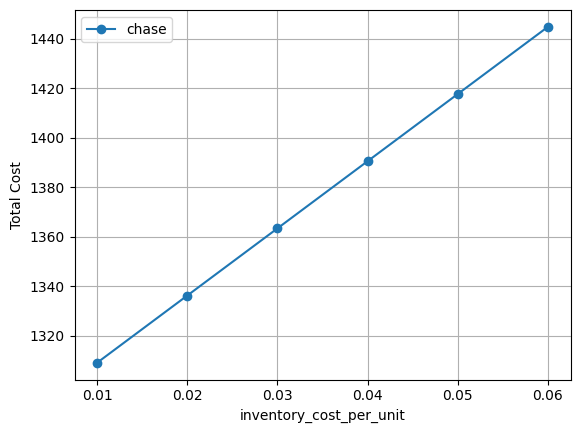

Strategy,inventory_cost_per_unit,chase
0,0.01,1309.15
1,0.02,1336.30
2,0.03,1363.45
3,0.04,1390.60
4,0.05,1417.75
5,0.06,1444.90


In [21]:


base = dict(
    demand=[300, 300, 350, 400, 450, 500, 650, 600, 475, 475, 450, 450],
    production_per_worker_regular=10,
    starting_inventory=50,
    desired_ending_inventory=50,
    initial_workers=40,
    wage_per_worker=2,
    hire_cost=1,
    layoff_cost=2,
    inventory_cost_per_unit=0.06,
    overtime_months=[5, 6, 7],
    overtime_percentage=0.2,
    overtime_wage_multiplier=1.5,
)

pivot_inv = sensitivity(
    param_name   = "inventory_cost_per_unit",
    param_values = [0.01,0.02,0.03,0.04,0.05,0.06],
    strategies   = ["chase"],
    base_kwargs  = base,
    plot         = True,
)
pivot_inv

In [29]:
#Jigsaw puzzle example
df_level, s_level = simulate_plan(
    demand                        = [600, 700, 400, 700, 500, 300],
    production_per_worker_regular = 100,
    starting_inventory            = 200,
    desired_ending_inventory      = 200,
    initial_workers               = 10,
    wage_per_worker               = 4,
    hire_cost                     = 1.5,
    layoff_cost                   = 4,
    inventory_cost_per_unit       = 0.05,
    overtime_months               = [0, 1],
    overtime_percentage           = 0.5,
    overtime_wage_multiplier      = 1.7,
    strategy                      = "chse",
)
display(df_level)
s_level
#Optimal strategy is level cost =291.5 vs chase=459.7

,Month,Workers,Hired,Laid off,Produced,Demand,End Inventory,Wage Cost,Overtime Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,1,5.0,0.0,5.0,750.0,600.0,350.0,20.0,17.0,0.0,20.0,17.5,74.5
1,2,5.0,0.0,0.0,750.0,700.0,400.0,20.0,17.0,0.0,0.0,20.0,57.0
2,3,5.0,0.0,0.0,500.0,400.0,500.0,20.0,0.0,0.0,0.0,25.0,45.0
3,4,5.0,0.0,0.0,500.0,700.0,300.0,20.0,0.0,0.0,0.0,15.0,35.0
4,5,5.0,0.0,0.0,500.0,500.0,300.0,20.0,0.0,0.0,0.0,15.0,35.0
5,6,5.0,0.0,0.0,500.0,300.0,500.0,20.0,0.0,0.0,0.0,25.0,45.0


{'Total Wage': 120.0,
 'Total Overtime': 34.0,
 'Total Hiring': 0.0,
 'Total Layoff': 20.0,
 'Total Inventory': 117.5,
 'Grand Total': 291.5}

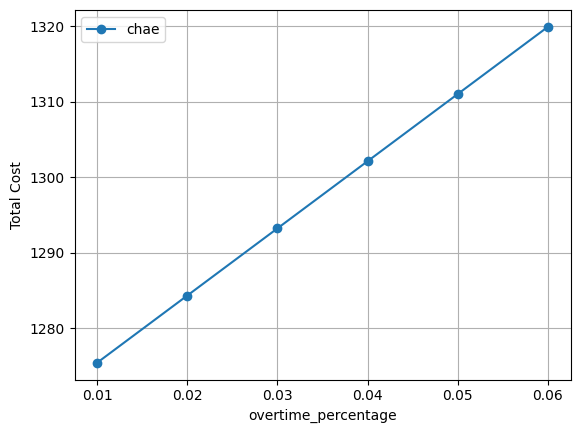

Strategy,overtime_percentage,chae
0,0.01,1275.41
1,0.02,1284.32
2,0.03,1293.23
3,0.04,1302.14
4,0.05,1311.05
5,0.06,1319.96


In [28]:
pivot_inv = sensitivity(
    param_name   = "overtime_percentage",
    param_values = [0.01,0.02,0.03,0.04,0.05,0.06],
    strategies   = ["chae"],
    base_kwargs  = base,
    plot         = True,
)
pivot_inv